# Obspy

[**Obspy**](https://github.com/obspy/obspy) ([Beyreuther *et al.*, 2010](https://pubs.geoscienceworld.org/ssa/srl/article/81/3/530/143693/ObsPy-A-Python-Toolbox-for-Seismology), [Megies *et al.*, 2011](https://www.annalsofgeophysics.eu/index.php/annals/article/view/4838), [Krischer *et al.*, 2015](https://iopscience.iop.org/article/10.1088/1749-4699/8/1/014003)) is an open-source Python project for seismological data processing. It was originally developed by a research team at Ludwig Maximilian University (LMU) Munich, Germany, and it is currently maintained as a community-driven open-source project by the ObsPy Development Team. It provides routines for:

- Handling waveform data and station metadata for different formats commonly used in seismology.
- Retrieving data from data centers (*e.g.*, [FDSN](https://www.fdsn.org/webservices/), [Earthscope/IRIS](https://www.earthscope.org), [NEIC](https://www.usgs.gov/programs/earthquake-hazards/national-earthquake-information-center-neic)).
- Processing, analyzing, and visualizing seismic signals (*e.g.*, plotting waveforms, spectrograms, and source mechanism beach balls). 

<img src="https://docs.obspy.org/_images/obspy_logo_full.svg" width="450" height="150" style="background-color: white; padding: 10px; border-radius: 4px;"/>

**ObsPy** simplifies the manipulation of seismological time series in Python, allowing the use of powerful packages like NumPy or SciPy. It is widely used across Seismology and Earthquake Engineering. 



# 0. Objectives

* Recogninze the Standard for the Exchange of Earthquake Data (SEED) data identification nomenclature.
* Read and visualize miniSEED and SAC file formats.
* Retrieve waveform, station, and event information from **FDSN** and **Earthscope Web Services**.
* Perform basic seismic data processing, including data detrending, instrument response removal, data filtering, and waveform rotation.

# 1. Installing Obspy

OpenQuake Engine is available on Windows, macOS, and Linux. The current release of **Obspy** (v1.5.1) requires `Python 3.12` or newer, and can be installed with pip or conda. For this workshop, we will also require **pyGMT** as a visualization tool. To handle the complexity underneath, we recommend creating a `venv` using **conda** in your terminal:

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda create --prefix ./.venv --channel conda-forge</code><br>
    <code style="color: #212121;">conda activate ./.venv</code><br>
    <code style="color: #212121;">conda install -c conda-forge pygmt obspy</code><br>
  </div>
</div>

We will additionally require the following dependencies:

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda install ipykernel</code><br>
    <code style="color: #212121;">pip install pyrotd</code><br>
    <code style="color: #212121;">pip install cartopy</code><br>
  </div>
</div>

More details about installation can be found at https://github.com/obspy/obspy/wiki#installation

After the installation, we can import the `obspy` package and check its version:

In [1]:
import obspy
import pygmt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(obspy.__version__)

1.5.1


# 2. Handling time

In **Obspy**, all time values are handled using the Coordinated Universal Time (UTC) with the `UTCDateTime()` class. This is based on [POSIX/UNIX timestamp](https://www.unixtimestamp.com) (defined as the number of seconds elapsed since midnight UTC of January 1, 1970) using nanoseconds as an integer for higher precision. Most commonly, time strings are specified following the [ISO8601:2004](https://www.iso.org/iso-8601-date-and-time-format.html) standard (`YYYY-MM-DDTHH:MM:SS`):

In [2]:
from obspy import UTCDateTime
# Current time initialize by leaven the class empty
print(UTCDateTime())

2026-09-17T13:57:39.675291Z


We can add or substract seconds to a `UTCDateTime()` object using `+`/`-`:

In [3]:
time = UTCDateTime("2020-01-01T00:00:00")
print(time)
print(time + 3665)

2020-01-01T00:00:00.000000Z
2020-01-01T01:01:05.000000Z


We can also calculate the time between two dates by substracting (`-`) two `UTCDateTime()` objects:

In [4]:
print((UTCDateTime()-UTCDateTime("2020-01-01T00:00:00"))/3600/24) # Days since 2020-01-01

2451.581752722523


# 3. File formats

**Obspy** uses the [Standard for the Exchange of Earthquake Data (`SEED`)](https://www.fdsn.org/pdf/SEEDManual_V2.4.pdf) naming convention to identify a time series and provide attribution to the owner of the data. SEED is an international data format maintained by FDSN for the archival and exchange of unprocessed seismological data. For a quick introduction to the SEED format, check [Ringler and Evans (2015)](https://pubs.geoscienceworld.org/ssa/srl/article/86/6/1717/315549/A-Quick-SEED-Tutorial). 

The format consists of **4 name components**:

- `Network code` (1-2 char, group of stations): Identifies the organization or network operating the station (assigned by the FDSN, *e.g.*, `N4` - Central and Eastern US Network/CEUSN or `US` - United States National Seismic Network).
- `Stations` (1-5 char, group of channels): Identifies the geographic location/station where many instruments could be. It is not unique; thus, it should always be used together with a network code (*e.g.,* [`US.CEH`](https://ds.iris.edu/mda/US/CEH/) is the seismic station **CEH** of the **US** network located at Chapel Hill, NC).
- `Location` (2 char). Distinguish similar instruments or similarly named channels at the same station (*e.g.*, `00` and `10`). At traditional stations, a `00` code implies the primary seismic channel. For further details, check the [FSDN website](https://docs.fdsn.org/projects/source-identifiers/en/latest/location-codes.html#location-codes).
- `Channels` (3 char). Three letters are used to identify: 
    - *Band/Sample rate*: `H` - High broadband (corner period/flat response $\geq$ 10 s, sample rate $80 - 250$ Hz), `B` - Broadband (corner period/flat response $\geq$ 10 s, sample rate $10 - 80$ Hz).
    - *Instrument type*: `H` - High gain seismometer (high amplification, better suited for distant events since they may clip), `L` - Low gain seismometer (low amplification, better suited for strong/regional events), `N` - Accelerometer.
    - *Sensor orientation*: `Z` - vertical, `N` - north/south, `E` - east/west (other option are `1`/`2`/`3` for othogonal components with non traditional orientations).

    For example, the channel `BHZ` refers to a broadband seismometer with high gain oriented to the vertical axis. For a complete list of channel namings, see the [Appendix A of SEED manual](https://www.fdsn.org/pdf/SEEDManual_V2.4.pdf).

**Obspy** uses a **NET.STA.LOC.CHA** ordering, *e.g.*, [**US.CBN.20.HNZ**](https://ds.iris.edu/mda/US/CBN/20/HNZ/) for the vertically oriented accelerometer in the CBN station operated by the US network located at the Fredericksburg Observatory, Virginia.

Data is classified into three main classes in **Obspy**:

- `Event` metadata. Information about seismic sources, such as hypocenter location (latitude, longitude, depth), magnitudes, and focal mechanisms.
- `Waveform` data. Ground-motion time series.
- `Station` metadata. Metadata describing the station, including network, geographic coordinates (latitude, longitude, elevation), and instrument responses.


## 3.1. Event data

Event metadata is handled by a `Catalog` object. A `Catalog` is a container of any number of `Event` objects, which have information about origin, magnitude, focal mechanisms, etc. The hierarchical `Catalog` class structure (**`Catalog`** > **`Event`** > **`Origin`/`Magnitude`/`Focal Mechanism`**) follows the standard [`QuakeML`](https://quake.ethz.ch/quakeml/) format.

<img src="https://docs.obspy.org/_images/Event.png" width="800" height="400" style="background-color: white; padding: 10px; border-radius: 4px;"/>

We can read the metadata using the `read_events()` function. As an example, we will work with a catalog of events $M_w \geq$ 2.0 near Sparta, NC, from 2019/08/09 to 2021/08/09, including the [$M_{w}$ 5.1 2020 Sparta Earthquake](https://earthquake.usgs.gov/earthquakes/eventpage/se60324281/executive). This catalog is in **data/2020_sparta/event/events_2019_2021.xml**, and it was retrieved from the[USGS Earthquake Catalog (ComCat)](https://earthquake.usgs.gov/earthquakes/search/) using **Obspy** tools (see [section 4](#-4.-Retrieving-data-from-datacenters)).

In [5]:
from obspy import read_events
cat = read_events("data/2020_sparta/event/events_2019_2021.xml")
print(cat)

22 Event(s) in Catalog:
2021-04-21T19:24:39.010000Z | +36.464,  -81.067 | 2.3  md | manual
2021-03-04T07:13:54.890000Z | +36.458,  -81.091 | 2.0  md | manual
...
2020-08-09T05:57:15.800000Z | +36.478,  -81.089 | 2.62 md | manual
2020-08-09T04:43:39.990000Z | +36.459,  -81.106 | 2.26 md | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'


The `Catalog` consists of 22 events. It behaves like a list of `Event` objects that we can loop over:

In [6]:
for event in cat:
    print(event)

Event:	2021-04-21T19:24:39.010000Z | +36.464,  -81.067 | 2.3  md | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=se60126623&format=quakeml")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='se', creation_time=UTCDateTime(2021, 7, 3, 16, 48, 55, 40000), version='19')
	    preferred_origin_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/se60126623/se/1619036714750")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/se60126623/se/1619036714750#magnitude")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements
Event:	2021-03-04T07:13:54.890000Z | +36.458,  -81.091 | 2.0  md | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=se60123728&format=quakeml")
	             event_t

The information in a `Catalog` object can be easily converted into a `pandas.DataFrame`:

In [7]:
lats, lons, deps, mags = [], [], [], []

for event in cat:
    orig = event.preferred_origin()
    mag = event.preferred_magnitude()

    lats.append(orig.latitude)
    lons.append(orig.longitude)
    deps.append(orig.depth / 1000.0)  # convert meters to km 
    mags.append(mag.mag)

df = pd.DataFrame({
    "latitude": lats,
    "longitude": lons,
    "depth": deps,
    "mag": mags,
})

df.head()

,latitude,longitude,depth,mag
0,36.463667,-81.066833,0.08,2.30
1,36.458167,-81.091000,0.08,2.00
2,36.464667,-81.102667,0.18,2.19
3,36.479500,-81.126667,0.77,2.17
4,36.491333,-81.131333,1.54,2.56


We can use this information to visualize the `Catalog` using **pyGMT**:

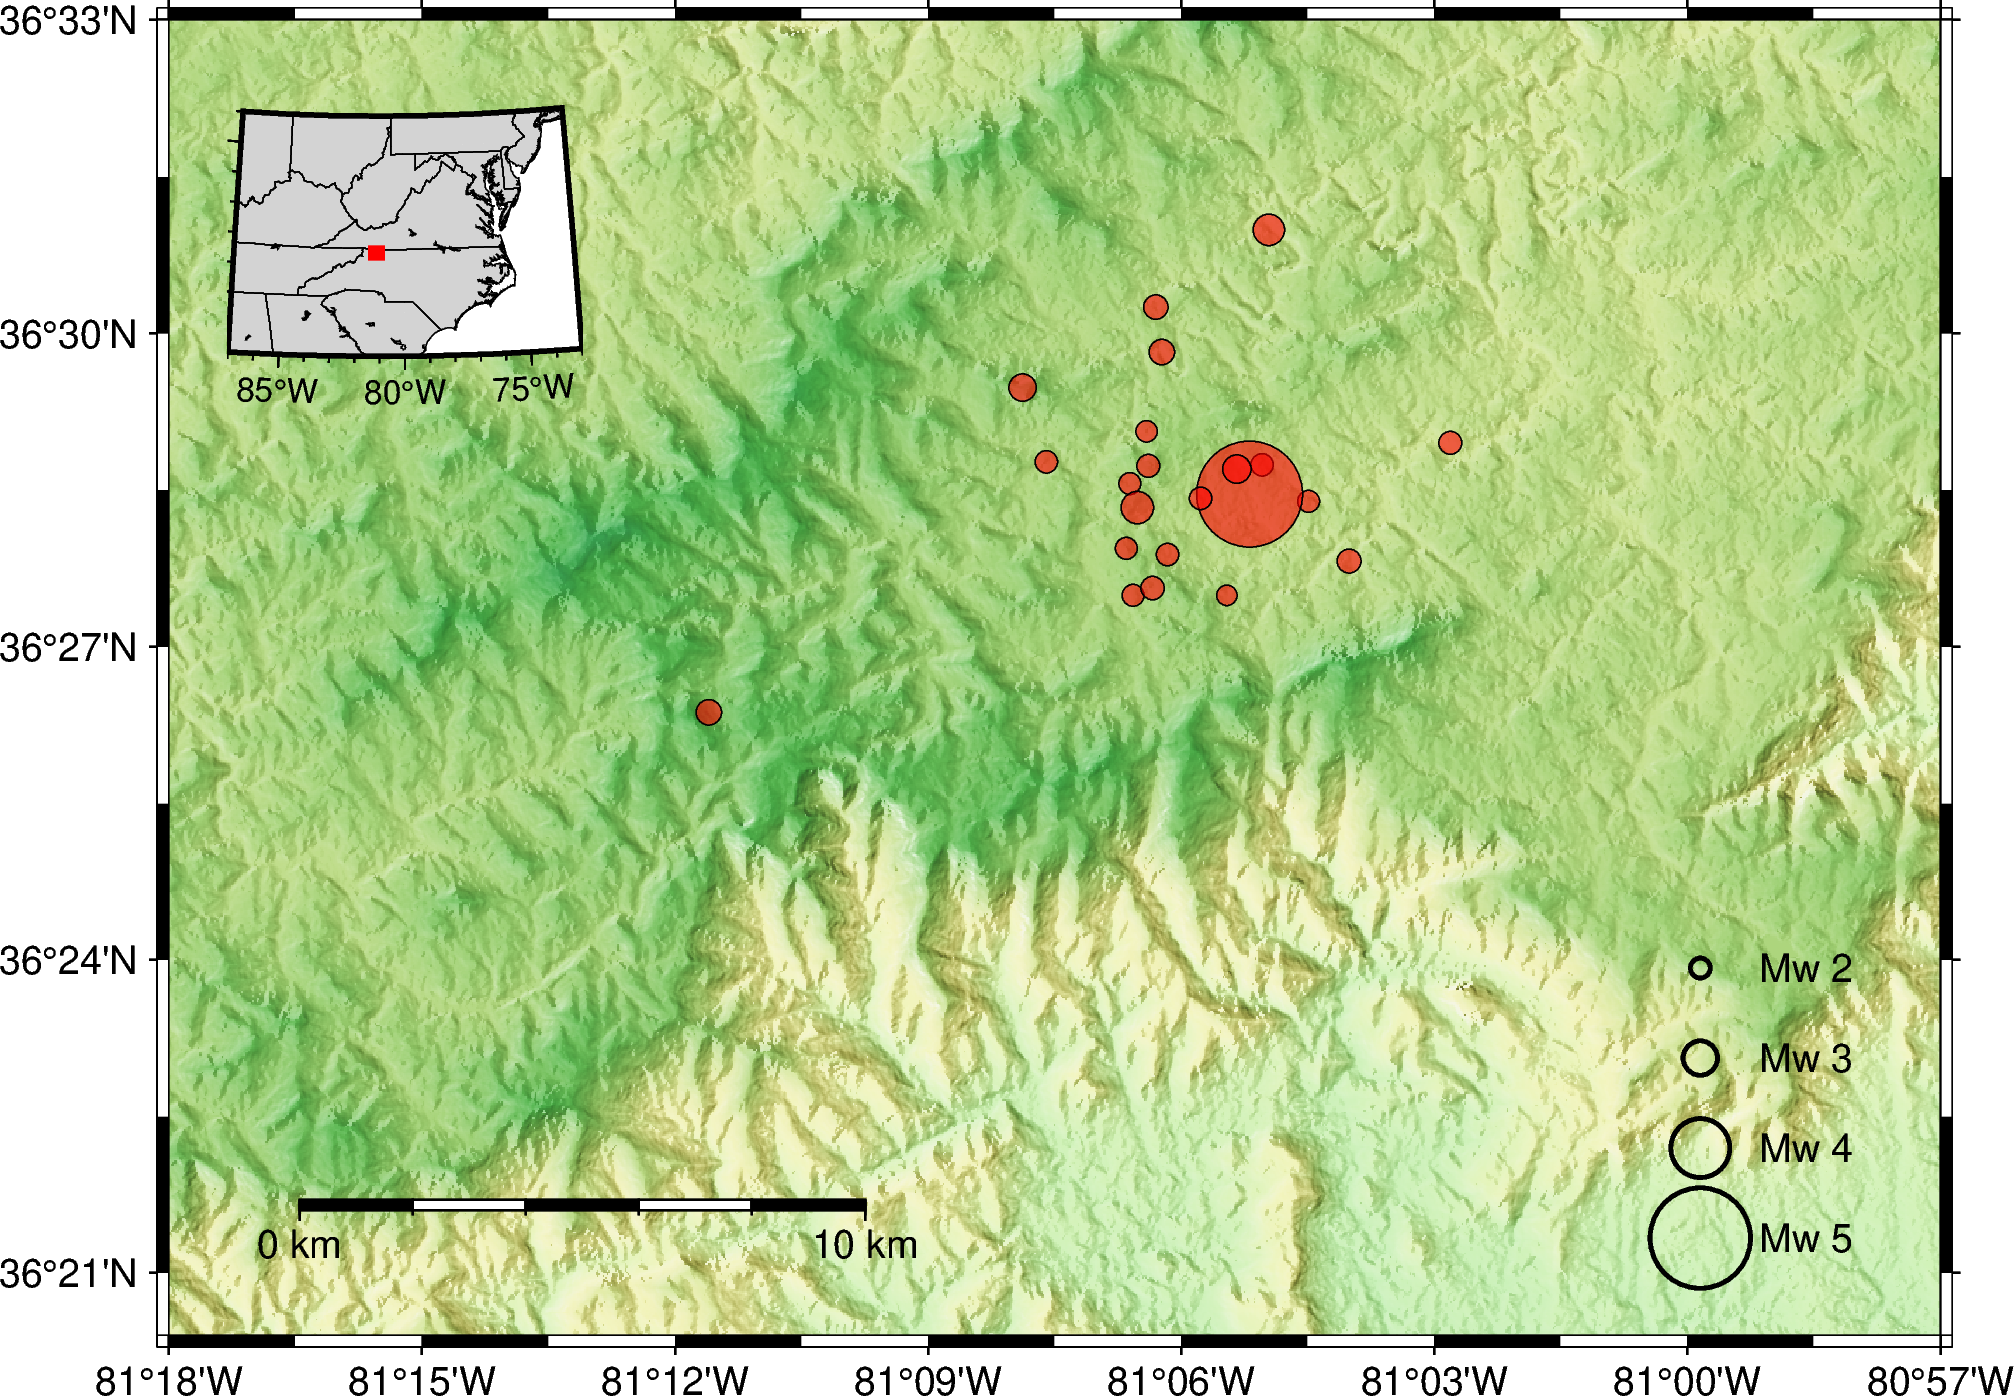

In [8]:
import io
from pygmt.params import Position

region = [-81.3, -80.95, 36.34, 36.55]
grid = pygmt.datasets.load_earth_relief(resolution="01s", region=region)
intensity_grid = pygmt.grdgradient(grid=grid, azimuth=[225, 315])

fig = pygmt.Figure()
fig.coast(region=region, projection="M-81/36/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
pygmt.makecpt(cmap="gmt/earth", series=[0, 5000])
fig.grdimage(grid=grid, region=region, cmap=True, shading=intensity_grid, transparency=20)
fig.basemap(frame=["a0.05f0.025", "WSne"])
fig.plot(x=df.longitude, y=df.latitude, style="c", size=0.06 * 1.7**df.mag, fill="red@40", pen="black")

with fig.inset(position=Position("TL", offset=(0.5, 0.3)), width=3):
    fig.coast(region=[-87, -73, 33, 41],projection="T-81/36/?", land="lightgray", borders=2, shorelines=True,water="white")
    fig.basemap(frame="p")
    rectangle = [[region[0], region[2], region[1], region[3]]]
    fig.plot(data=rectangle, style="r+s", pen="2p,red")

legend = io.StringIO("\n".join(f"S 0.5 c {0.06 * 1.7**m:.2f} - 1p 1 Mw {m}" for m in [2, 3, 4, 5]))
legend2 = io.StringIO("""M -81 36.5 10+u+f""") # M = code for Map Scale, -81/36.5 = lot/lan where the scale is evaluated, 10 = length (km), +u = add units, +f = fancy scale bar
fig.legend(spec=legend, position=Position("BR", offset=[0.6,0.3]), line_spacing=2.3, box=False)
fig.legend(spec=legend2, position="jBL+o1.5c/0.5c+w4c")
fig.show()

We can filter a `Catalog` using the `filter()` method based on keys like `magnitude`, `time`, `longitude`, `latitude`, or `depth`. For example, if we want to check the events of $M_w \geq$ 5.0 from 2020 onwards:

In [9]:
cat_filtered = cat.filter("magnitude >= 5", "time >= 2020-01-01")
print(cat_filtered)

1 Event(s) in Catalog:
2020-08-09T12:07:37.650000Z | +36.474,  -81.087 | 5.1  mw | manual


We can export a `Catalog` using the `write()` method:

In [10]:
cat_filtered.write("data/2020_sparta/event/output/events_2020_2021_mag5.xml", format="QUAKEML")

For more information about the $M_{w}$ 5.1 2020 Sparta Earthquake, see [Figueiredo *et al.* (2022)](https://rock.geosociety.org/net/gsatoday/science/G517A/GSATG517A.pdf). 

## 3.2. Waveform data

Waveform data are represented by a `Stream` object in **Obspy**. A `Stream` is a container for any number of `Trace` objects. They consist of single, equally sampled waveform data alongside the necessary meta-information. Each `Trace` object has a `data` attribute, which is a one-dimensional NumPy array. All additional information is located in the `stats` attribute, including the corresponding network, station, location, channel, start time, and sampling rate. 



<img src="https://docs.obspy.org/_images/Stream_Trace.png" width="700" height="400" style="background-color: white; padding: 10px; border-radius: 4px;"/>

**Obspy** supports several file formats commonly used in seismology, including miniseed (MSEED) and SAC. [Miniseed](https://ds.iris.edu/ds/nodes/dmc/data/formats/miniseed/) is a subset of the SEED standard for time-series data. It is a standard followed by most data centers because it can deal with gaps/overlaps, incorporate multiple components per file, and has high compressibility. [SAC (Seismic Analysis Code)](https://ds.iris.edu/ds/support/faq/17/sac-file-format/) data format generally contains a single component per file and cannot handle gaps/overlaps. It was developed jointly with the [Seismic Analysis Code software](https://ds.iris.edu/ds/nodes/dmc/software/downloads/sac/), a popular program for analyzing time series data.


We can read waveform data using the `read()` function. It automatically detects the file format and creates the `Stream` object. As an example, we will work with the time series data from the [$M_{w}$ 5.1 2020 Sparta Earthquake](https://earthquake.usgs.gov/earthquakes/eventpage/se60324281/executive) recorded by station [**IU.WCI**](https://ds.iris.edu/mda/IU/WCI/?starttime=1997-07-17&endtime=2599-12-31) (Wyandotte Cave, Indiana, USA). 


For a `.MSEED` file, we have:

In [12]:
from obspy import read
st1 = read("data/2020_sparta/waveform/mseed/IU_WCI_2020_sparta.miniseed")
print(st1)


6 Trace(s) in Stream:
IU.WCI.00.BH1 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.00.BH2 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.00.BHZ | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.10.BH1 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples
IU.WCI.10.BH2 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples
IU.WCI.10.BHZ | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples


If we are working with `.SAC` files, we can use an `*` as a wildcard to read any file name with `.SAC` extension and load them all into a single `Stream`:

In [13]:
# Read all SAC files matching a pattern
st2 = read("data/2020_sparta/waveform/SAC/*.SAC")
print(st2)


6 Trace(s) in Stream:
IU.WCI.00.BH1 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.00.BH2 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.00.BHZ | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.969538Z | 20.0 Hz, 13200 samples
IU.WCI.10.BH1 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples
IU.WCI.10.BH2 | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples
IU.WCI.10.BHZ | 2020-08-09T12:07:45.019538Z - 2020-08-09T12:18:44.994538Z | 40.0 Hz, 26400 samples


`Stream` objects behave like a list of `Trace` objects, so we can loop over them:

In [14]:
for tr in st1:
    print(tr.id)

IU.WCI.00.BH1
IU.WCI.00.BH2
IU.WCI.00.BHZ
IU.WCI.10.BH1
IU.WCI.10.BH2
IU.WCI.10.BHZ


We can check the specific information stored in the `stats` attribute of a specific `Trace`:

In [15]:
print(st1[0].stats)

         network: IU
         station: WCI
        location: 00
         channel: BH1
       starttime: 2020-08-09T12:07:45.019538Z
         endtime: 2020-08-09T12:18:44.969538Z
   sampling_rate: 20.0
           delta: 0.05
            npts: 13200
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'M', 'number_of_records': 69, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 278016})


`Steam` objects offer a `plot()` method for preview of the waveform:

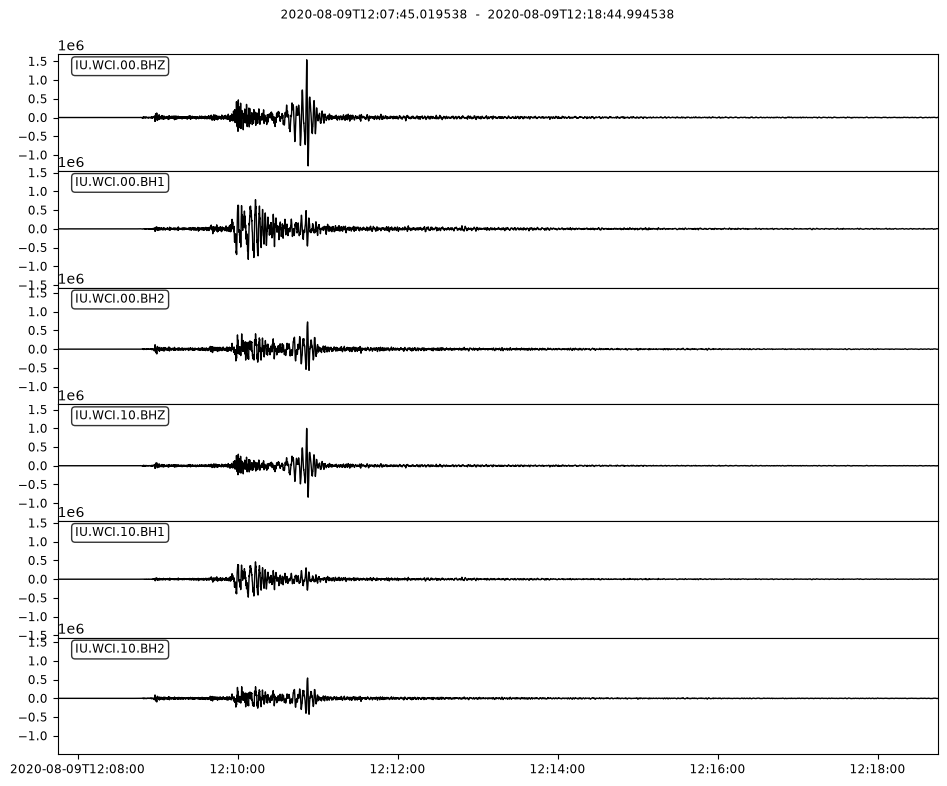

In [16]:
st1.plot(size=(1000,800));

Most methods in **Obspy** modify the object they are called upon (**mutuating methods**); thus, it is always recommended to create a copy of the `Steam` using the `copy()` method. Additionally, we can use only a part of the `Stream` using the `select()` method. For example, if we want to select only the principal seismic channel:

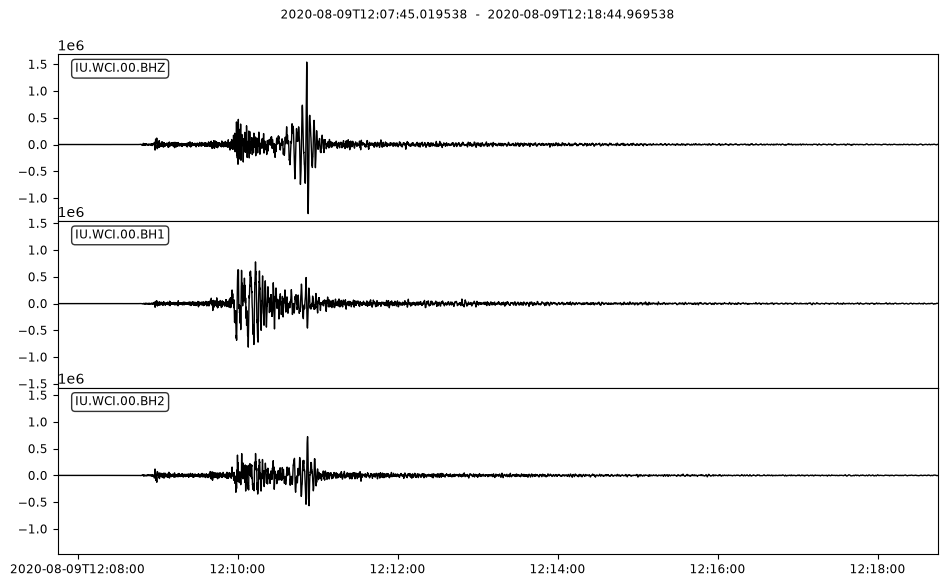

In [17]:
# Create a copy
st1_copy = st1.copy()
# Select the channels and locations
st1_00 = st1_copy.select(location="00")
st1_00.plot(size=(1000,600));

Similar filters can be applied based on `network`, `station`, `component`, among others. If we want to select only the vertical components:

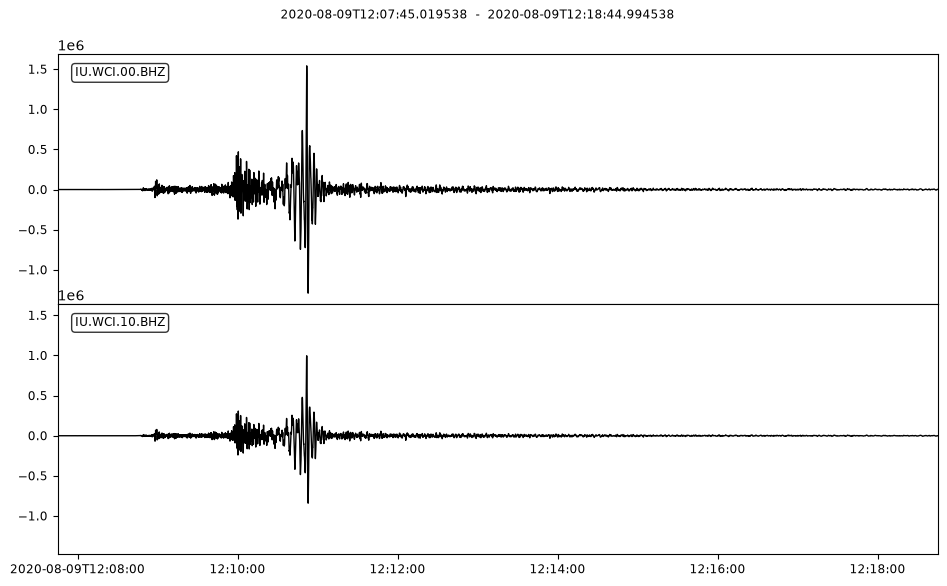

In [18]:
st1_Z = st1_copy.select(channel="*Z") # Other option: component="Z"
st1_Z.plot(size=(1000,600));

We can cut all `Traces` of a `Stream` to a given start and end time using the `trim()` method:

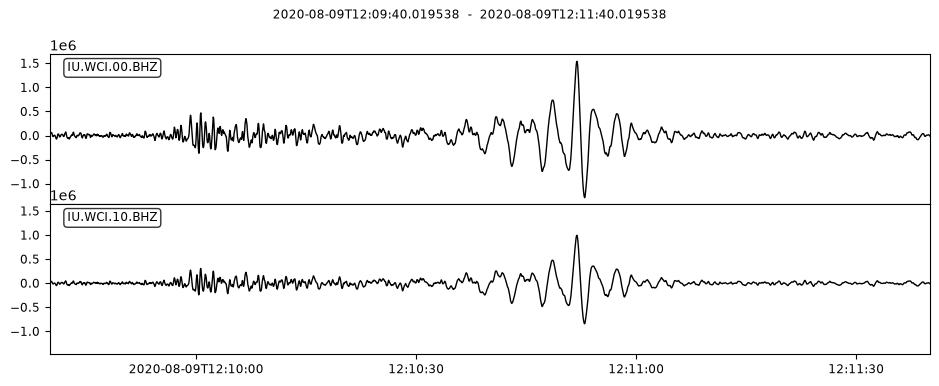

In [19]:
# Selecting time window
starttime = UTCDateTime("2020-08-09T12:09:40")
endtime = starttime + 2*60 # 2 minute

# Trim the stream and plot it
st1_Z_trimmed = st1_Z.copy().trim(starttime=starttime, endtime=endtime)
st1_Z_trimmed.plot(size=(1000,400));

We can export a `Stream` using the `save()` method:

In [20]:
st2.write("data/2020_sparta/waveform/output/IU.WCI.00.mseed", format="mseed")

## 3.3. Station data

Station metadata (information that describes the station and the data collected by the instrumentation) is handled by an `Inventory` object. The hierarchical `Inventory` class structure (**`Inventory`** > **`Network`** > **`Station`** > **`Channel`**) uses the FSDN [`StationXML`](https://www.fdsn.org/xml/station/) schema. Other supported formats include `RESP` and `SEED`.

<img src="https://docs.obspy.org/_images/Inventory.png" width="800" height="400" style="background-color: white; padding: 10px; border-radius: 4px;"/>

We can read the metadata using the `read_inventory()` function. For the `IU.WCI` station:

In [21]:
from obspy import read_inventory
inventory = read_inventory("data/2020_sparta/metadata/IU.WCI.xml", format="STATIONXML")
print(inventory)


Inventory created at 2026-09-15T20:20:34.723100Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=201...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			IU
		Stations (1):
			IU.WCI (Wyandotte Cave, Indiana, USA)
		Channels (3):
			IU.WCI.00.BHZ, IU.WCI.00.BH1, IU.WCI.00.BH2


Similar to `Stream` objects, we can use only a subset of an `Inventory` using the `select()` method:

In [22]:
metadata_IU_WCI_00_BHZ = inventory.select(network="IU", station="WCI", location="00", channel="BHZ")
print(metadata_IU_WCI_00_BHZ)

Inventory created at 2026-09-15T20:20:34.723100Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=201...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			IU
		Stations (1):
			IU.WCI (Wyandotte Cave, Indiana, USA)
		Channels (1):
			IU.WCI.00.BHZ


The coordinates of a specific channel are available using the `get_coordinates()` method:

In [23]:
inventory.get_coordinates("IU.WCI.00.BHZ")

{'latitude': 38.2289,
 'longitude': -86.2939,
 'elevation': 78.0,
 'local_depth': 132.0}

We can access further specific information about the networks, stations, and/or their channels by navegating through `Inventory` objects. For example, we can print the instrument response of the `IU.WCI.00.BHZ` channel: 

In [24]:
print(inventory.networks[0].stations[0].channels[0].response)

Channel Response
	From m/s (Velocity in Meters Per Second) to counts (Digital Counts)
	Overall Sensitivity: 4.29526e+09 defined at 0.050 Hz
	3 stages:
		Stage 1: PolesZerosResponseStage from m/s to V, gain: 2560
		Stage 2: CoefficientsTypeResponseStage from V to counts, gain: 1.67772e+06
		Stage 3: CoefficientsTypeResponseStage from counts to counts, gain: 1


The instrument response can be plotted using the `plot_response()` method:

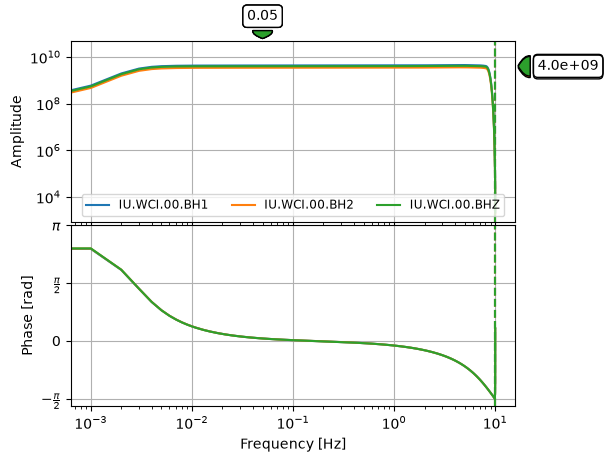

In [25]:
inventory[0].plot_response(min_freq=0.001);

<div class="alert alert-block alert-info">
<b>What is the intrument response?</b> <br>
<b>Seismometers</b> record signals (raw data) in digital counts, which are proportional to physical units (<i>e.g.</i>, displacement, velocity, etc.) for certain frequencies. The instrument response provides the information required to make the transformation in the frequency domain (<i>i.e.</i>, amplitude - gain - and phase - time delay of the instrument at different frequencies - response functions). The above is based on the Fourier Transform: <br><br>



<img src="https://upload.wikimedia.org/wikipedia/commons/6/61/FFT-Time-Frequency-View.png" width="400" height="300" style="background-color: white; padding: 10px; border-radius: 4px;"/>

For more information about Fourier transform and instrument response, check this <a href="https://www.youtube.com/watch?v=spUNpyF58BYl"> explanatory video</a> and the <a href="https://docs.fdsn.org/projects/stationxml/en/latest/response.html">FSDN website</a>. 
</div>




We can export `Inventory` objects using the `write()` method:

In [26]:
inventory.write("data/2020_sparta/metadata/output/IU.WCI.xml", format="STATIONXML")

# 4. Retrieving data from datacenters

**Obspy** accesses seismological information via the [FDSN web service](https://www.fdsn.org/webservices/). Other supported data centers include [USGS](https://earthquake.usgs.gov/data/comcat/), [Earthworn Central](http://www.earthwormcentral.org/), [Syngine Service](https://ds.iris.edu/ds/products/syngine/), and [NEIC-CWB](https://www.usgs.gov/publications/overview-national-earthquake-information-center-acquisition-software-system).

To connect to the web service provider, we need to initialize a **`Client()`** object. Depending on the `Client`, we can request:

* **Event** (**`get_events()`**): Event data returned as a **`Catalog`** object.
* **Station Metadata** (**`get_stations()`**): StationXML file returned as an **`Inventory`** object.
* **Waveforms** (**`get_waveform()`**): MiniSEED format (other formats are also available) returned as a **`Stream`** object.

## 4.1. Event data

In this example, we will download information on the [$M_{w}$ 5.8 2011 Mineral, VA](https://earthquake.usgs.gov/earthquakes/eventpage/se609212/executive) earthquake. A `Client` object can be initialized either with the base URL of any [FDSN web service]() or with a shortcut name which will be mapped to a FDSN URL. The list of shortcuts is:

In [27]:
from obspy.clients.fdsn.header import URL_MAPPINGS
for key in sorted(URL_MAPPINGS.keys()):
   print("{0:<11} {1}".format(key,  URL_MAPPINGS[key]))

AUSPASS     https://auspass.edu.au
BGR         https://eida.bgr.de
BGS         https://eida.bgs.ac.uk
EARTHSCOPE  https://service.earthscope.org
EARTHSCOPE+USGS https://service.earthscope.org
EIDA        http://eida-federator.ethz.ch
EMSC        https://www.seismicportal.eu
EPOSFR      https://seisdata.epos-france.fr
ETH         https://eida.ethz.ch
GEOFON      https://geofon.gfz.de
GEONET      https://service.geonet.org.nz
GFZ         https://geofon.gfz.de
ICGC        https://ws.icgc.cat
IESDMC      http://batsws.earth.sinica.edu.tw
IGN         https://fdsnws.sismologia.ign.es
INGV        https://webservices.ingv.it
IPGP        https://ws.ipgp.fr
IRIS        https://service.earthscope.org
IRISDMC     https://service.earthscope.org
IRISPH5     https://service.earthscope.org
ISC         https://www.isc.ac.uk
KAGSR       http://sdis.emsd.ru
KNMI        https://rdsa.knmi.nl
KOERI       https://eida.koeri.boun.edu.tr
LMU         https://erde.geophysik.uni-muenchen.de
NCEDC       https://se

In our case, the information will be query from **USGS**:

In [28]:
from obspy.clients.fdsn import Client
client = Client("USGS")

If we are interested in a specific event, the easiest approach is to use the event identifier (`eventid`) assigned by the corresponding data center. In the **USGS Earthquake Catalog**, the `eventid` can be checked in the [**Shakemap** metadata](https://earthquake.usgs.gov/earthquakes/eventpage/se609212/shakemap/metadata). For the **$M_{w}$ 5.8 2011 Mineral, VA** earthquake:

In [29]:
cat = client.get_events(eventid="se609212")
print(cat)

1 Event(s) in Catalog:
2011-08-23T17:51:04.250000Z | +37.910,  -77.936 | 5.8  mw | manual


We can also query based on general information such as **time**, **magnitude range**, **location (lon/lat)**, or **distance** from a specific point (for details, check [get_events()](https://docs.obspy.org/packages/autogen/obspy.clients.fdsn.client.Client.get_events.html) documentation):

In [30]:
eventtime = UTCDateTime("2011-08-23T17:51:04") # 2011 Mineral, VA earthquake

cat2 = client.get_events(starttime=eventtime - 3600, 
                        endtime=eventtime + 3600, 
                        minlongitude = -95,
                        maxlongitude= -75,
                        minlatitude= 25,
                        maxlatitude= 41,
                        minmagnitude=5.0)
print(cat2)


1 Event(s) in Catalog:
2011-08-23T17:51:04.250000Z | +37.910,  -77.936 | 5.8  mw | manual


## 4.2. Station metadata

We will retrieve the information on the stations active during the **$M_{w}$ 5.8 2011 Mineral, VA** earthquake via [Earthscope](https://www.earthscope.org) webservices. The query with `get_stations()` method is similar to `get_events()`, but we have to specify a **`level`** argument. This argument controls the amount of information returned in the `Inventory` object. The options include:

* `network`: only return information on networks matching the criteria.
* `station`: return information on all matching stations.
* `channel`: return information on available channels in all stations` networks matching the criteria.
* `response`: include instrument response for all matching channels **&rarr;** large data file.

We are particularly interested in nearby stations; thus, we will limit our results to stations within 2.5 degrees ($\approx$ 250 km) from the epicenter (`maxradius`). For a preliminary exploration of the available data, we will request information at a `channel` level: 

In [31]:
client = Client("Earthscope")

# Infomration about the event
starttime = eventtime - 5*60
endtime = starttime + 5*60
lon_event = cat[0].preferred_origin().longitude
lat_event = cat[0].preferred_origin().latitude

inventory = client.get_stations(longitude = lon_event,
                                latitude = lat_event,
                                maxradius = 2.5,
                                network="*", 
                                station="*",
                                location="*",
                                channel = "BH*,HN*",
                                level = "channel",
                                starttime=starttime,
                                endtime=endtime
                                )
print(inventory)

Inventory created at 2026-09-17T13:59:00.129700Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=201...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (7):
			GS, NM, NP, PN, SS, TA, US
		Stations (14):
			GS.CVRD (Virginia aftershock response)
			NM.CVVA (Charlottesville,VA(CERI))
			NP.2507 (VAMC)
			NP.2511 (VAMC)
			NP.2549 (Giles County Courthouse)
			NP.2555 (Fire Station 25)
			PN.PPHYL (C.D. Hylton High School, Woodbridge, VA, USA)
			PN.PPLCH (Loudoun County High School, Leesburg, VA, USA)
			PN.PPPVH (-)
			SS.NCAT (NC A&T Campus)
			TA.O56A (Blue Knob State Park, Imler, PA, USA)
			US.BLA (Blacksburg, Virginia, USA)
			US.CBN (Corbin (Fredericksburg Observatory), Virginia, USA)
			US.MCWV (Mont Chateau, West Virginia, USA)
		Channels (51):
			GS.CVRD..BHZ, GS.CVRD..BHN, GS.CVRD..BHE, GS.CVRD..HNZ, 
			GS.CVRD..HNN, GS.CVRD..HNE, NM.CVVA.00.HNZ, NM.CVVA.00.HNN, 
		

Fourteen stations from seven networks met the criteria. To analyze the spatial distribution of the stations, we  will convert the information in the `Inventory` object into a `pandas.DataFrame` and then plotted it in **pyGMT**. Additionally, we can calculate the distance from each station to the epicenter using the `gps2dist_azimuth()` function. For this, we have to define:

- `lat1`/`lon1`: Latitude and longitude of the initial point (°). 
- `lat2`/`lon2`: Latitude and longitude of the final point (°). 

This function also calculates the forward and backward azimuths between the points, which are required for waveform rotation.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTCxFpVCdZAaHwTLlDwUS3RAQJMwqij2Ubopq5UtligzSorxu6KAgOMGUJ-&s=10" width="400" height="300" style="background-color: white; padding: 10px; border-radius: 4px;"/>

In [32]:
from obspy.geodetics import gps2dist_azimuth

ev_lat = cat[0].preferred_origin().latitude
ev_lon = cat[0].preferred_origin().longitude
networks, stations, lon, lat, dist, az, baz = [], [], [], [], [], [], []

for net in inventory:
    for sta in net:
        networks.append(net.code)
        stations.append(sta.code)
        lon.append(sta.longitude)
        lat.append(sta.latitude)
        dist_m, az_sta, baz_sta = gps2dist_azimuth(ev_lat, ev_lon, sta.latitude, sta.longitude)
        dist.append(dist_m/1000)  # Convert to kilometers
        az.append(az_sta)
        baz.append(baz_sta)

df = pd.DataFrame({
        "network": networks,
        "station": stations,
        "latitude": lat,
        "longitude": lon,
        "distance": dist,
        "azimuth": az,
        "back_azimuth": baz
})

df_stations = df.sort_values(by="distance").reset_index(drop=True)
df_stations.head()
        

,network,station,latitude,longitude,distance,azimuth,back_azimuth
0,GS,CVRD,38.068600,-77.808098,20.930895,32.521330,212.600260
1,NM,CVVA,38.022000,-78.532000,53.807586,283.581692,103.215241
2,US,CBN,38.204600,-77.373200,59.281631,56.306910,236.654055
3,PN,PPHYL,38.650002,-77.379997,95.513192,30.468244,210.812905
4,NP,2555,38.951110,-77.335850,126.938695,24.210332,204.583588


The location of the stations and the event epicenter are shown below:

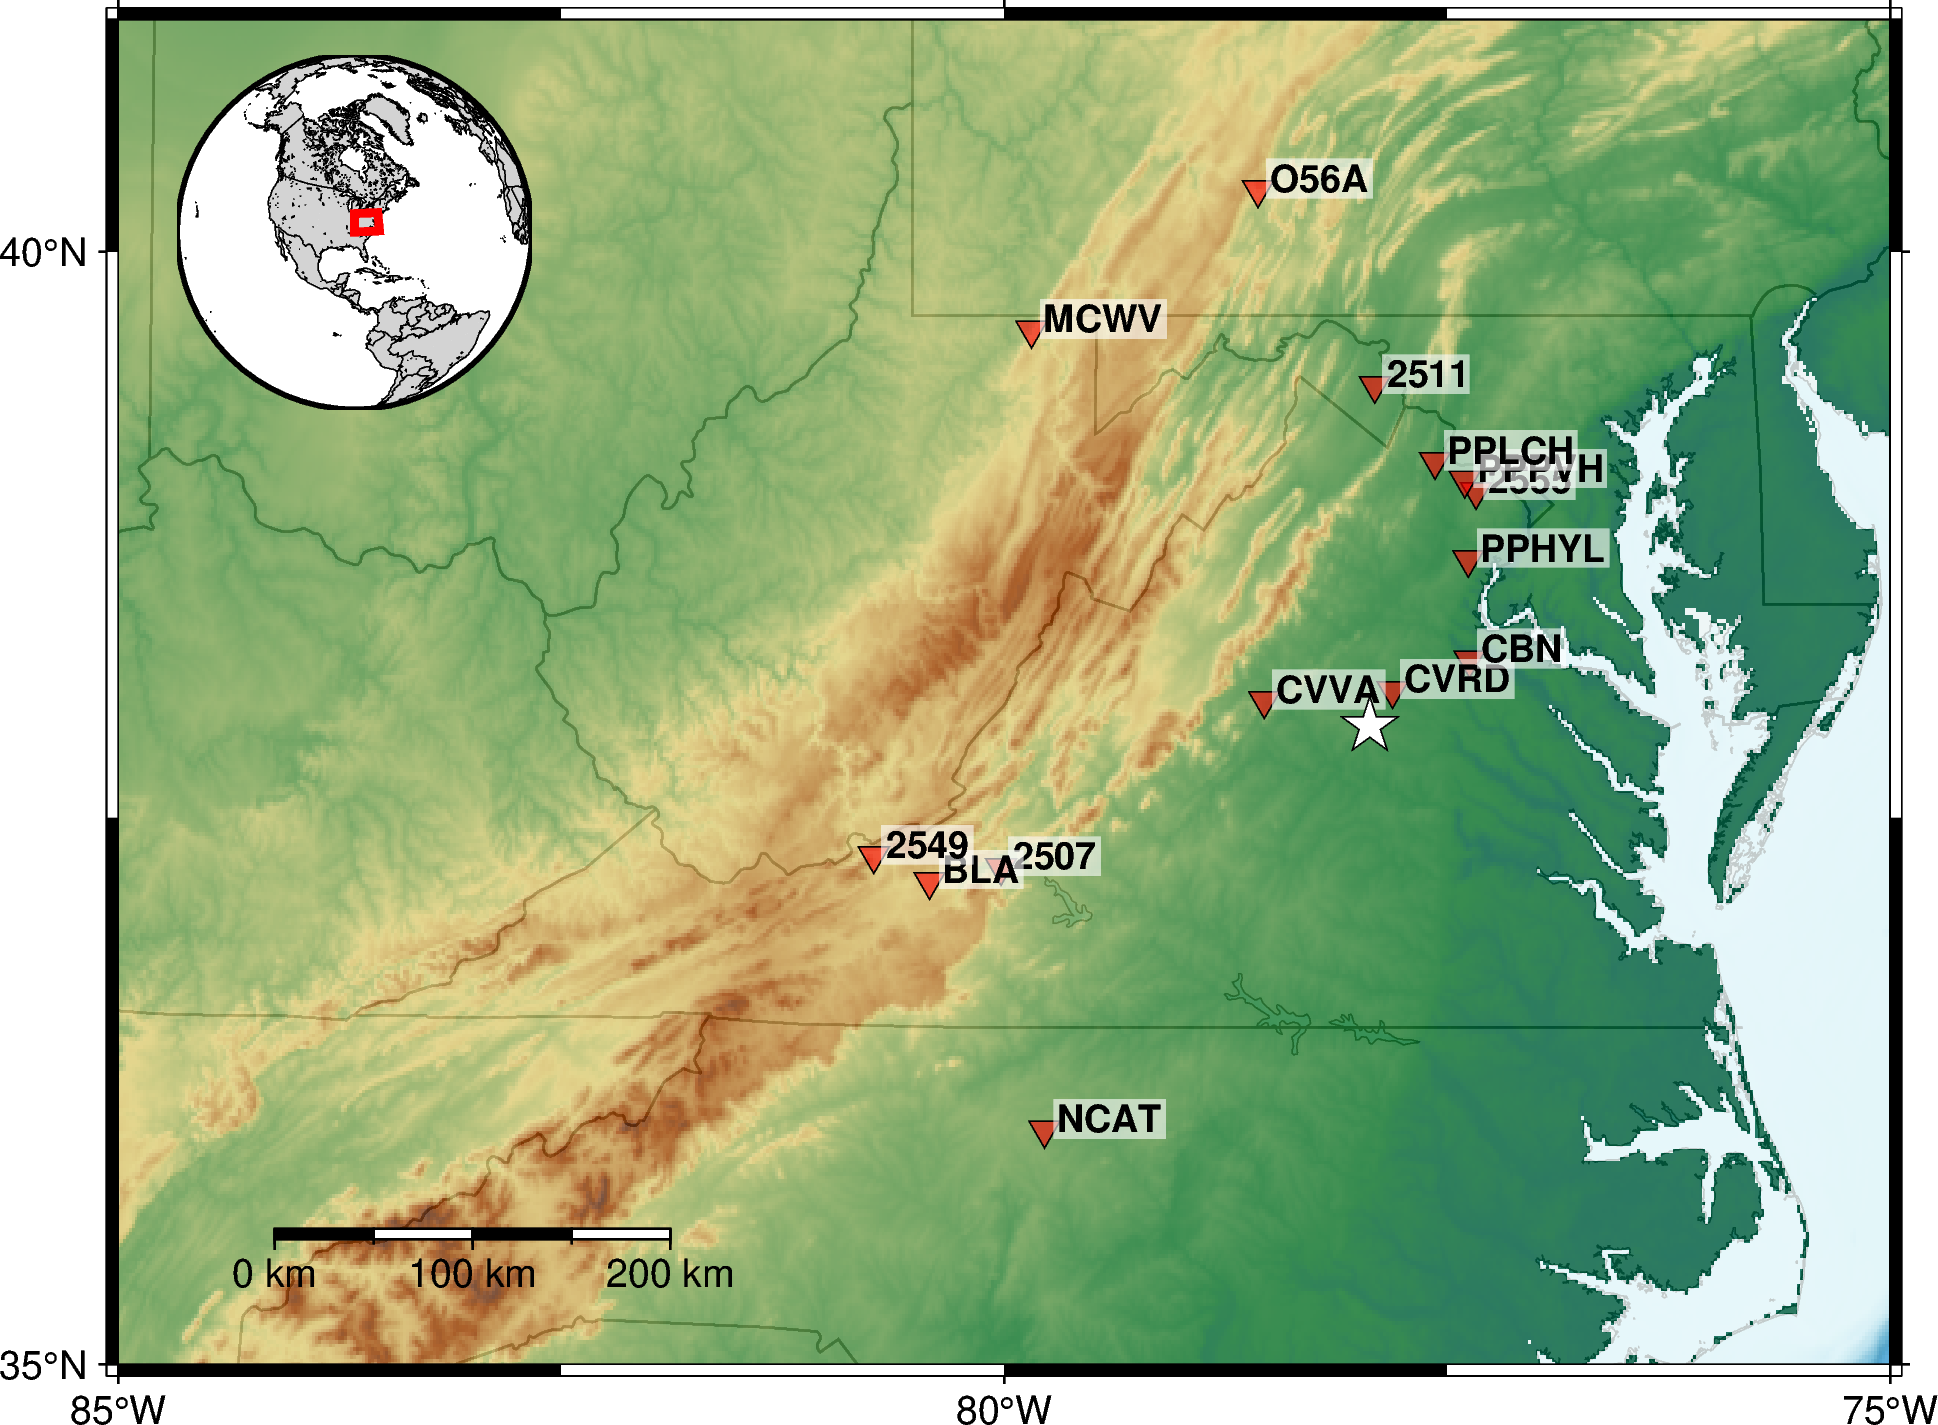

In [33]:
region = [-85, -75, 35, 41]
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region)
intensity_grid = pygmt.grdgradient(grid=grid, azimuth=[225, 315])

fig = pygmt.Figure()
fig.coast(region=region, projection="M-81/36/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
pygmt.makecpt(cmap="geo", series=[-8000, 5000])
fig.grdimage(grid=grid, region=region, cmap=True, shading=intensity_grid, transparency=20)
fig.basemap(frame=["a5f2.5", "WSne"])
fig.plot(x=df_stations.longitude, y=df_stations.latitude, style="i0.3c", fill="red@40", pen="black")
fig.text(
        x=df_stations.longitude, y=df_stations.latitude,
        text=df_stations.station, font="9p,Helvetica-Bold,black",
        justify="ML",offset="0.1c/0.1c",fill="white@40"
    )
fig.plot(x=ev_lon, y=ev_lat, style="a0.5c",fill="white",pen="black")

with fig.inset(position=Position("TL", offset=(0.5, 0.3)), width=3):
    fig.coast(region="g",
        projection="G-85/35/?", land="lightgray", borders=1, shorelines=True,water="white")
    fig.basemap(frame="p")
    rectangle = [[region[0], region[2], region[1], region[3]]]
    fig.plot(data=rectangle, style="r+s", pen="2p,red")

legend2 = io.StringIO("""M -81 36.5 200+u+f""") # M = code for Map Scale, -81/36.5 = lot/lan where the scale is evaluated, 10 = length (km), +u = add units, +f = fancy scale bar
fig.legend(spec=legend2, position="jBL+o1c/0.5c+w4c")
fig.show()

In the next sections, we will focus on station [**US.CBN**](https://ds.iris.edu/mda/US/CBN) (Corbin - Fredericksburg Observatory, Virginia, USA). To retrieve its instrument response:


In [34]:
inv_CBN = client.get_stations(
                                network="US", 
                                station="CBN",
                                location="*",
                                channel = "BH*,HN*",
                                level = "response",
                                starttime=starttime,
                                endtime=endtime
                                )
print(inv_CBN)

Inventory created at 2026-09-17T13:59:09.913500Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=201...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			US
		Stations (1):
			US.CBN (Corbin (Fredericksburg Observatory), Virginia, USA)
		Channels (6):
			US.CBN.00.BHZ, US.CBN.00.BH1, US.CBN.00.BH2, US.CBN.20.HNZ, 
			US.CBN.20.HN1, US.CBN.20.HN2


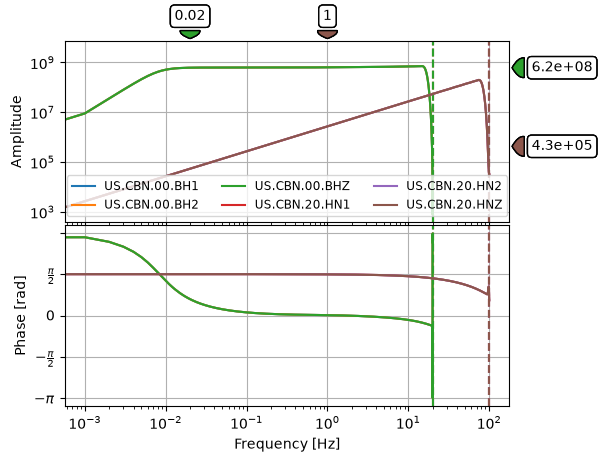

In [35]:
inv_CBN[0].plot_response(min_freq=0.001);

<div class="alert alert-block alert-info">
<b>Question</b>: Why do the instrument response of the Seismometers (BH) and the Accelerometers (HN) differ?
</div>

## 4.2. Waveform data

The query with `get_waveforms()` method is similar to `get_events()` and `get_stations()`. We will retrieve the waveforms recorded during the **$M_{w}$ 5.8 2011 Mineral, VA** earthquake by the broadband seismographs (`BH`) and accelerometers (`HN`) of station [**US.CBN**](https://ds.iris.edu/mda/US/CBN) (Corbin - Fredericksburg Observatory, Virginia, USA):

In [342]:
starttime = eventtime - 10
endtime = starttime + 3*60

sta_CBN_rawdata = client.get_waveforms(network = "US",
                                    station = "CBN",
                                    location = "*",
                                    channel = "BH*,HN*",
                                    starttime = starttime,
                                    endtime = endtime)
print(sta_CBN_rawdata)

6 Trace(s) in Stream:
US.CBN.00.BH1 | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 40.0 Hz, 7201 samples
US.CBN.00.BH2 | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 40.0 Hz, 7201 samples
US.CBN.00.BHZ | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 40.0 Hz, 7201 samples
US.CBN.20.HN1 | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 200.0 Hz, 36001 samples
US.CBN.20.HN2 | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 200.0 Hz, 36001 samples
US.CBN.20.HNZ | 2011-08-23T17:50:54.000000Z - 2011-08-23T17:53:54.000000Z | 200.0 Hz, 36001 samples


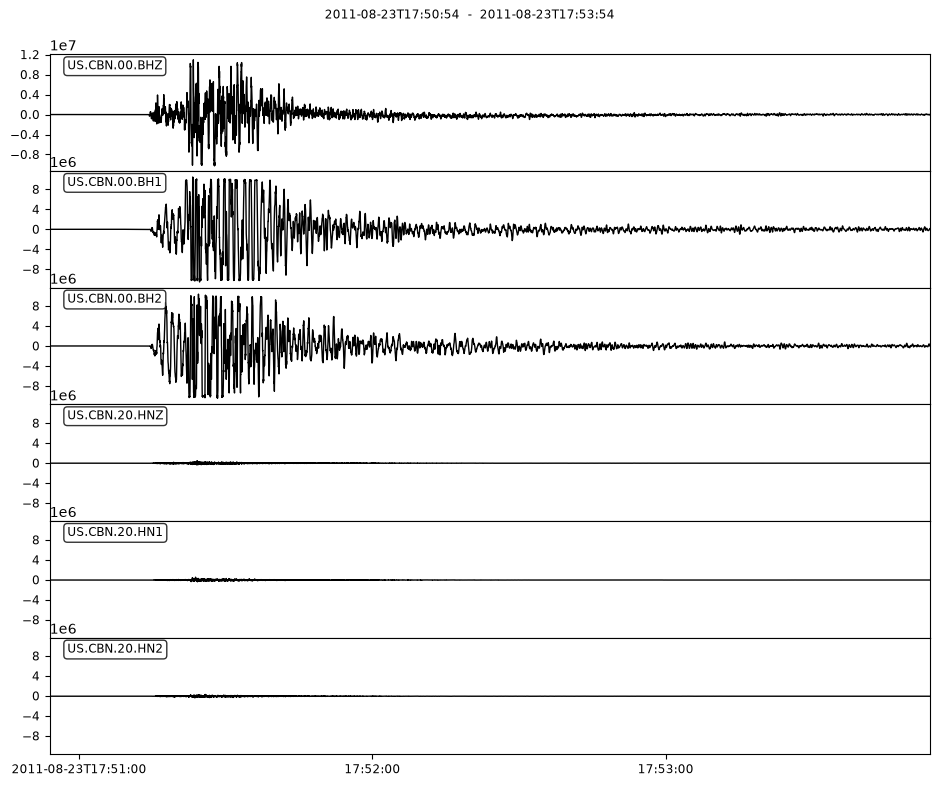

In [343]:
sta_CBN_rawdata.plot(size=(1000,800));

The waveforms show that the ground motion exceeded the maximum measurement limit of the seismometers, causing the records to be clipped. Thus, we will center our analysis on the accelerometer records:

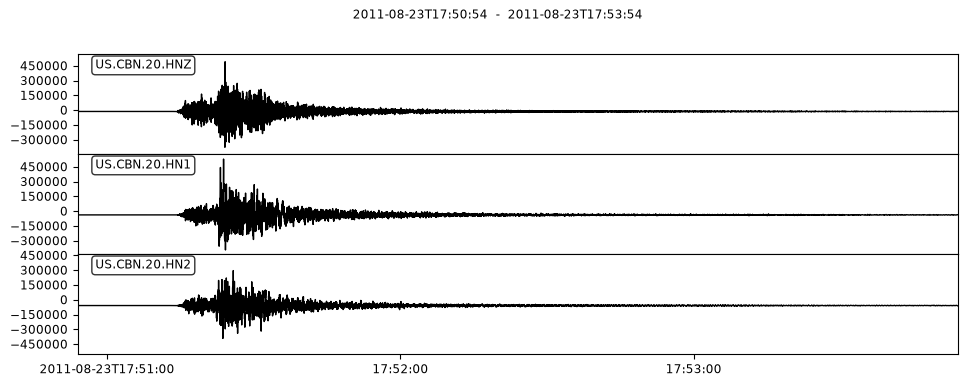

In [344]:
sta_CBN_acc = sta_CBN_rawdata.select(channel="HN*")
sta_CBN_acc.plot(size=(1000,400));

We can download the waveforms from all the stations identified in [section 4.2](#-4.2-station-metadata) by looping through the `Inventory`:

3 Trace(s) in Stream:
US.BLA.20.HNZ  | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples
US.CBN.20.HNZ  | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples
US.MCWV.20.HNZ | 2011-08-23T17:51:04.000001Z - 2011-08-23T17:53:03.995001Z | 200.0 Hz, 24000 samples


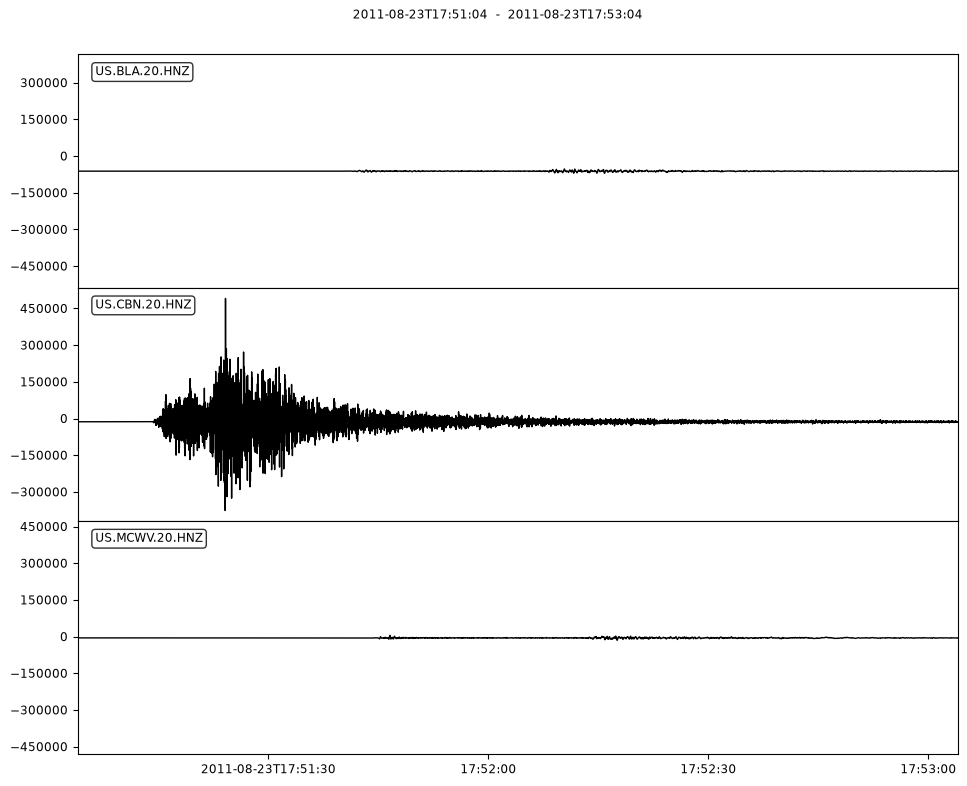

In [61]:
from obspy import Stream
st = Stream()

for net in inventory:
    for sta in net:
        try:
            st += client.get_waveforms(network =net.code, 
                                       station =sta.code, 
                                       location="*", 
                                       channel = "HNZ",
                                       starttime = starttime,
                                       endtime = endtime)
        except:
            pass

print(st)
st.plot(size=(1000,800));

# 5. Basic Signal Processing

Seismic records contain noise that can distort the ground-motion signal at both high and low frequencies. Therefore, the data must be processed to reduce noise levels and ensure that the signal is suitable for further analysis. The processing protocol varies depending on the application, but may include some of the following steps:

- `Detrend`: Remove distortions and shifts of the reference baseline (which can result in unphysical velocities and displacements) by subtracting one or more linear or low-order polynomial functions.
- `Downsample/resample`: Reduce the sampling frequency (reduce the number of data points in the time series). It helps to reduce high-frequency noise.
- `Instrument correction`: Remove distorting effects of the instrument and transform raw data into physical units 
- `Cut`: Window the record based on the estimated *P-wave* arrival time and duration of shaking.
- `Taper`: Smooth out the ends of a signal to mitigate spectral leakage (caused when a finite signal has discontinuities at its ends). For more information about tapers, see [link1](https://qingkaikong.blogspot.com/2016/10/signal-processing-why-do-we-need-taper.html) and [link2](https://community.sw.siemens.com/s/article/window-types-hanning-flattop-uniform-tukey-and-exponential). 
- `Low-pass filtering`: Remove high-frequency noise from the record.
- `High-pass filtering`: Remove low-frequency noise from the record.

In this workshop, we will partially follow the default waveform processing steps used by USGS ([Thompson *et al.*, 2025](https://pubs.geoscienceworld.org/ssa/srl/article/96/1/538/646608/Automated-Near-Real-Time-Ground-Motion-Processing)). The protocol consists of:

```mermaid
flowchart LR
    A[Detrend <br>Remove mean] --> B[Detrend <br>Remove linear trend]
    B --> C[Remove <br>Instrument response]
    C --> D[Taper]
    D --> E[Low-pass <br>filter]
    E --> F[High-pass <br>filter]
```

 


## 5.1 Downloading data

We will focus on the waveform recorded in channel **HN2** by station [**US.CBN**](https://ds.iris.edu/mda/US/CBN) (Corbin - Fredericksburg Observatory, Virginia, USA) during the **$M_{w}$ 5.8 2011 Mineral, VA** earthquake. First, we will re-download the data and the instrument response:

1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples


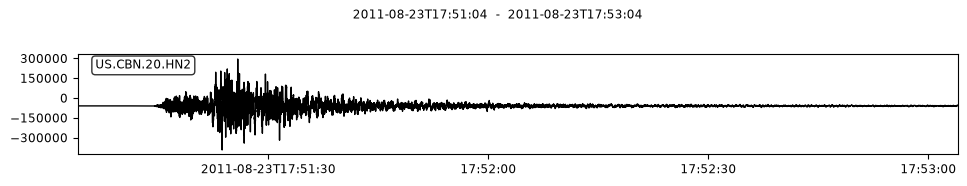

In [71]:
starttime = eventtime 
endtime = starttime + 2*60

sta_CBN_rawdata = client.get_waveforms(network = "US",
                                    station = "CBN",
                                    location = "*",
                                    channel = "HN2",
                                    starttime = starttime,
                                    endtime = endtime)
print(sta_CBN_rawdata)
sta_CBN_rawdata.plot(size=(1000,200));

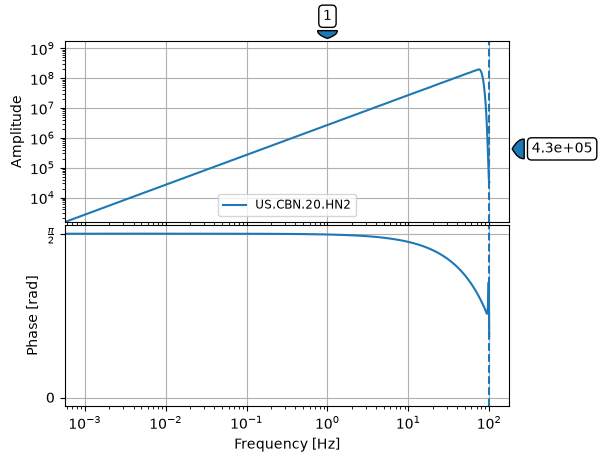

In [63]:
inv_CBN = client.get_stations(
                          network = "US",
                          station = "CBN",
                          location = "*",
                          channel = "HN2",
                          level = "response",
                          starttime = starttime,
                          endtime = endtime)

inv_CBN.plot_response(min_freq=0.001);

## 5.2. Detrend: Remove mean

We can remove the mean from a `Trace` using the `detrend()` method. This operation is performed in place on the `Trace`, so the raw data is not accessible anymore afterwards. To keep your original data, we will create a copy of our `Trace` using the `copy()` method.

There are many methods available that can be specified using the `type` attribute, including subtracting the mean, linear, or polynomial functions. To remove the mean: 

In [72]:
sta_CBN_processed = sta_CBN_rawdata.copy()
sta_CBN_processed.detrend(type="demean")


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

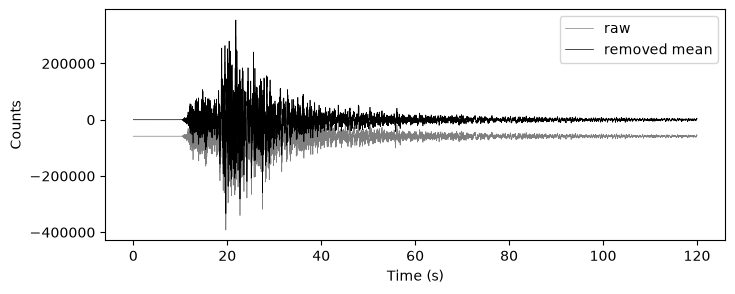

In [73]:
plt.figure(figsize=(8,3))
data1 = [sta_CBN_rawdata[0].times(), sta_CBN_rawdata[0].data]
plt.plot(data1[0], data1[1], color='gray', label='raw', linewidth=0.5)
data2 = [sta_CBN_processed[0].times(), sta_CBN_processed[0].data]
plt.plot(data2[0], data2[1], color='black', label='removed mean', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Counts")

plt.legend()
plt.show()

## 5.3. Detrend: Remove linear trend

To remove the linear trend:

In [74]:
sta_CBN_processed.detrend(type="linear")


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

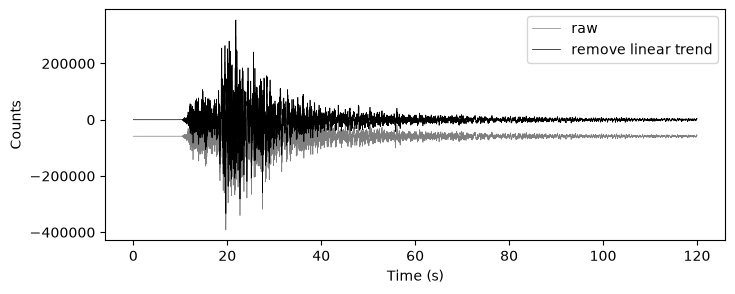

In [75]:
plt.figure(figsize=(8,3))
data1 = [sta_CBN_rawdata[0].times(), sta_CBN_rawdata[0].data]
plt.plot(data1[0], data1[1], color='gray', label='raw', linewidth=0.5)
data2 = [sta_CBN_processed[0].times(), sta_CBN_processed[0].data]
plt.plot(data2[0], data2[1], color='black', label='remove linear trend', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Counts")

plt.legend()
plt.show()

## 5.4. Remove instrument response

In **Obspy**, we can deconvolve the instrument response of a `Trace` using the `remove_response()` method. For this, we need to define:

- `inventory`: Metadata of the instrument with instrument response information
- `output`: Requested physical unit. We usually use the native quantity for the instrument, *i.e.*, velocity (`VEL`) for seismometers and acceleration (`ACC`) for accelerometers.
- `prefilter`: A prefilter in the frequency domain with four corner frequencies (corner frequencies determine the range of frequencies that are passed, partially reduced, or completely attenuated) to avoid overamplification when removing the instrument response.
- `water_level`: A numerical safeguard that stops extreme noise amplification at frequencies where the seismometer is insensitive (at very low or very high frequencies, the instrument's sensitivity drops close to zero). The default value is 60 dB.

For more information about the process, check [Havskov and Alguacil (2016)](https://link.springer.com/chapter/10.1007/978-3-319-21314-9_2).

1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

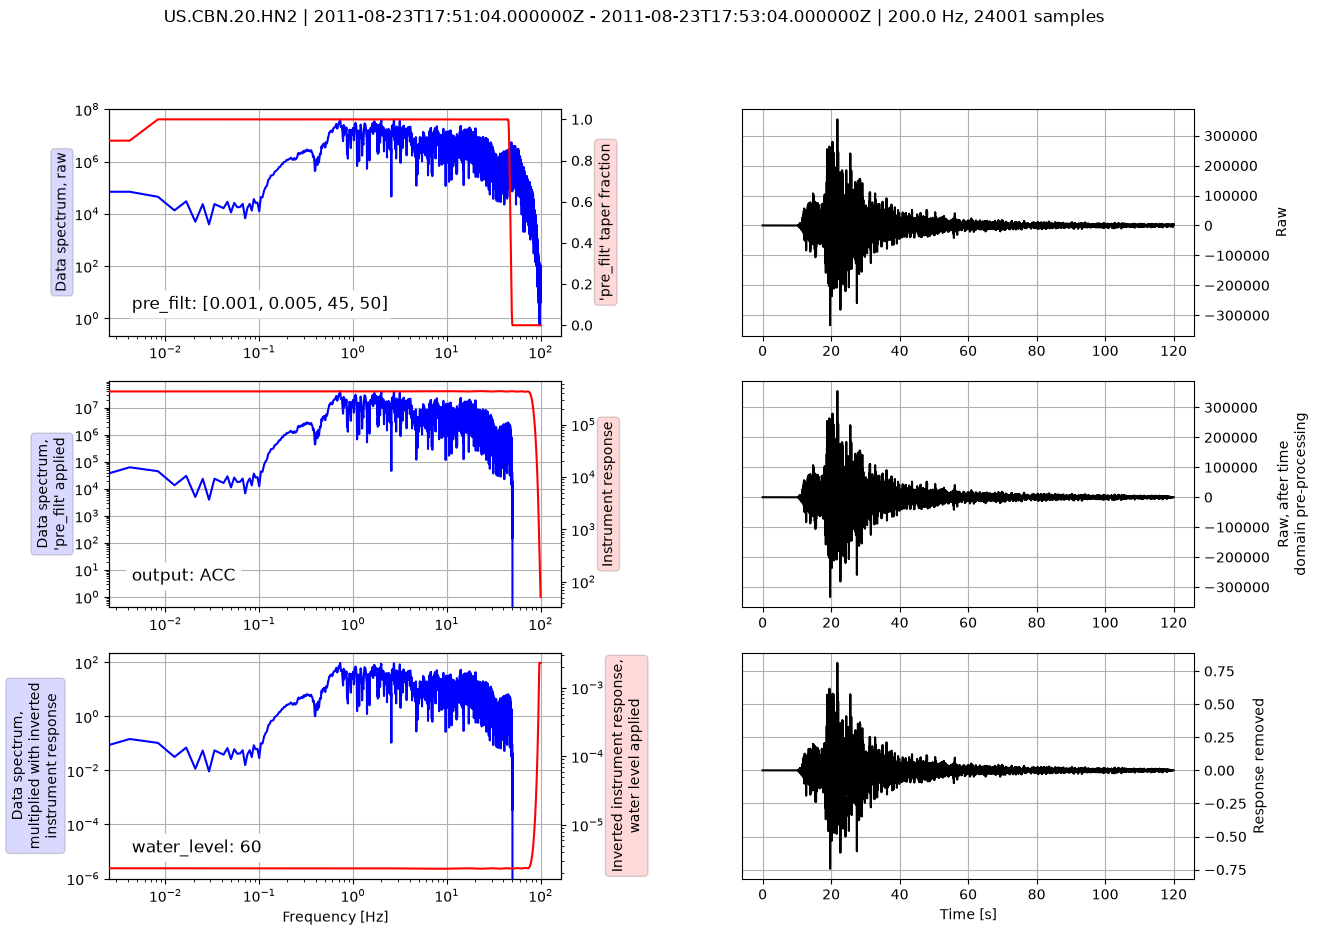

In [76]:
pre_filt = [0.001, 0.005, 45, 50]
sta_CBN_processed.remove_response(inventory=inv_CBN, output='ACC', pre_filt=pre_filt, water_level=60, plot=True)

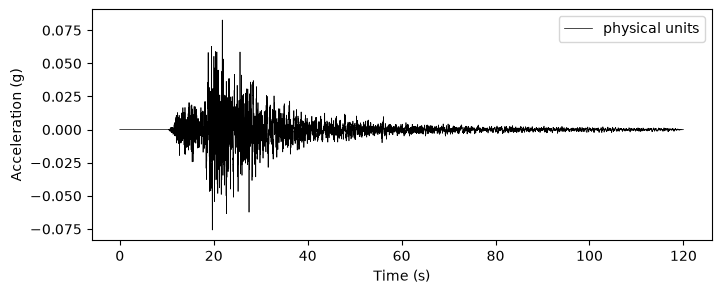

In [77]:
plt.figure(figsize=(8,3))
data = [sta_CBN_processed[0].times(), sta_CBN_processed[0].data/9.81]
plt.plot(data[0], data[1], color='black', label='physical units', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

plt.legend()
plt.show()

## 5.5. Taper

To smooth the ends of our `Trace`, we can use the `taper()` method. We have to define:

- `type`: Taper method, available methods include `cosine`, `hann`, `hamm`, `parzen`.
- `max_percentage`: Taper length as decimal percentage applied at one end.
- `side`: specify if the tapper should be applied at left half (`left`), right half (`right`), or both (`both`).


<img src="https://docs-be.ni.com/bundle/labwindows-cvi/page/advancedanalysisconcepts/guid-12ee66d8-d6ba-4aab-9373-1a0e5a6347a6-help-web.png?_LANG=enus" width="300" height="400" style="background-color: white; padding: 10px; border-radius: 4px;"/><br>


<img src="https://community.sw.siemens.com/servlet/rtaImage?eid=ka6KZ00000000iw&feoid=00N4O000006Yxpf&refid=0EM4O000001143C" width="400" height="200" style="background-color: white; padding: 10px; border-radius: 4px;"/>


For our case, we will use a 5% Hanning (`hann`) taper on both sides:

In [78]:
sta_CBN_processed.taper(max_percentage=0.05, type='hann', side='both')

1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

## 5.6. Filters

There are four main types of filters: high-pass, low-pass, band-pass, and band-stop filters. A high-pass filter allow high frequencies of the waveform through, blocking all frequencies lower than a specified corner frequency. It is used to remove low-frequency noises in the signal. On the other hand, a low-pass filter cuts the higher frequencies above the corner frequency, removing high frequency noise. In contrast, band-pass and band-stop filters have two corner frequencies, defining a frequency band to pass and to stop, respectively.

<img src="https://www.allaboutcircuits.com/uploads/articles/Types_of_Filters.jpg" width="400" height="300" style="background-color: white; padding: 10px; border-radius: 4px;"/>

We can apply a filter to a `Trace` using the `filter()` method. For this, we have to specify:

- `Type`: type of filter (*e.g.*, high-pass, low-pass)
- `freq`: Corner frequency
- `corner`: Order of the filter

For our example, we will use a high-pass fifth-order filter (Butterworth). The selection of the corner frequency is the most critical aspect of the filtering. It is usually assigned as a function of the unfiltered record signal-to-noise ratio (SNR). For our example, we will use  a corner frequency of 0.05. For more details about the selection of the corner frequency, see [Thompson *et al.*, 2025](https://pubs.geoscienceworld.org/ssa/srl/article/96/1/538/646608/Automated-Near-Real-Time-Ground-Motion-Processing).

In [79]:

sta_CBN_processed.filter(type='highpass', corners=5, freq=0.05)


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

We will also apply a low-pass fifth-order filter with corner frequency of 40 Hz:

In [80]:
sta_CBN_processed.filter(type='lowpass', corners=5, freq=40)


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

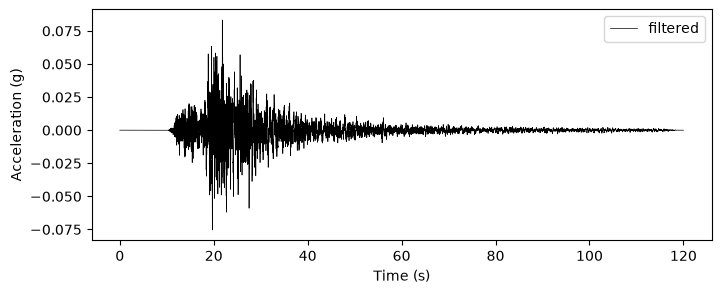

In [81]:
plt.figure(figsize=(8,3))
data = [sta_CBN_processed[0].times(), sta_CBN_processed[0].data/9.81]
plt.plot(data[0], data[1], color='black', label='filtered', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

plt.legend()
plt.show()

## 5.7. Acceleration/Velocity/Displacement time series

With our processed record, we can calculate the Intensity Measures `**IM**` of interest. For example, for `PGA`:

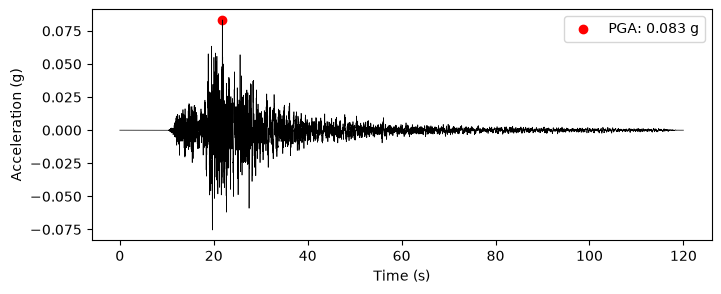

In [82]:
pga = np.max(np.abs(sta_CBN_processed[0].data))/9.81
pga_index = np.argmax(np.abs(sta_CBN_processed[0].data))
pga_time = pga_index * sta_CBN_processed[0].stats.delta

plt.figure(figsize=(8,3))
data = [sta_CBN_processed[0].times(), sta_CBN_processed[0].data/9.81]
plt.scatter(pga_time, sta_CBN_processed[0].data[pga_index]/9.81, color="red", marker="o", label=f"PGA: {pga:.3f} g")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

plt.legend()
plt.show()

To obtain the velocity time series, we can integrate the acceleration time series using the `integrate()` method:

In [83]:
sta_CBN_processed_VEL = sta_CBN_processed.copy()
sta_CBN_processed_VEL.integrate()


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

We can calculate the `PGV` as:

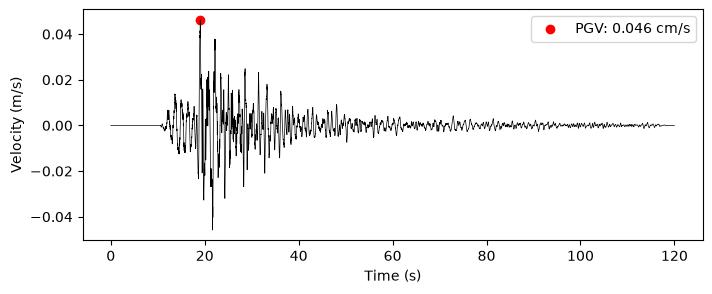

In [84]:
pgv = np.max(np.abs(sta_CBN_processed_VEL[0].data))
pgv_index = np.argmax(np.abs(sta_CBN_processed_VEL[0].data))
pgv_time = pgv_index * sta_CBN_processed_VEL[0].stats.delta

plt.figure(figsize=(8,3))
data = [sta_CBN_processed_VEL[0].times(), sta_CBN_processed_VEL[0].data]
plt.scatter(pgv_time, sta_CBN_processed_VEL[0].data[pgv_index], color="red", marker="o", label=f"PGV: {pgv:.3f} cm/s")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")

plt.legend()
plt.show()

By integrating the velocity time series, we get the displacement time series:

In [633]:
sta_CBN_processed_DIS = sta_CBN_processed_VEL.copy()
sta_CBN_processed_DIS.integrate()


1 Trace(s) in Stream:
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples

And the `PGD`:

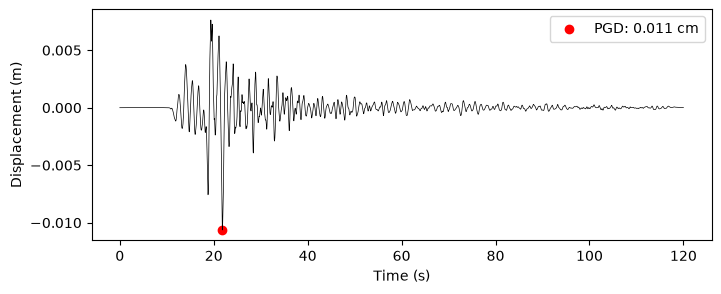

In [634]:
pgd = np.max(np.abs(sta_CBN_processed_DIS[0].data))
pgd_index = np.argmax(np.abs(sta_CBN_processed_DIS[0].data))
pgd_time = pgd_index * sta_CBN_processed_DIS[0].stats.delta

plt.figure(figsize=(8,3))
data = [sta_CBN_processed_DIS[0].times(), sta_CBN_processed_DIS[0].data]
plt.scatter(pgd_time, sta_CBN_processed_DIS[0].data[pgd_index], color="red", marker="o", label=f"PGD: {pgd:.3f} cm")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")

plt.legend()
plt.show()

## 5.7. Rotation

We can rotate the two horizontal components of our waveforms to any angle using the `rotate()` method. For this, we have to define:

- `method`: Direction of rotation, *e.g.*, `NE->RT` rotates the North- and East- components to a radial and transverse components
- `back_azimuth`: Back azimuth from station to source (°)

For our example, we will retrieve the two horizontal componentes recorded at the **US.CBN** station:

2 Trace(s) in Stream:
US.CBN.20.HN1 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples
US.CBN.20.HN2 | 2011-08-23T17:51:04.000000Z - 2011-08-23T17:53:04.000000Z | 200.0 Hz, 24001 samples


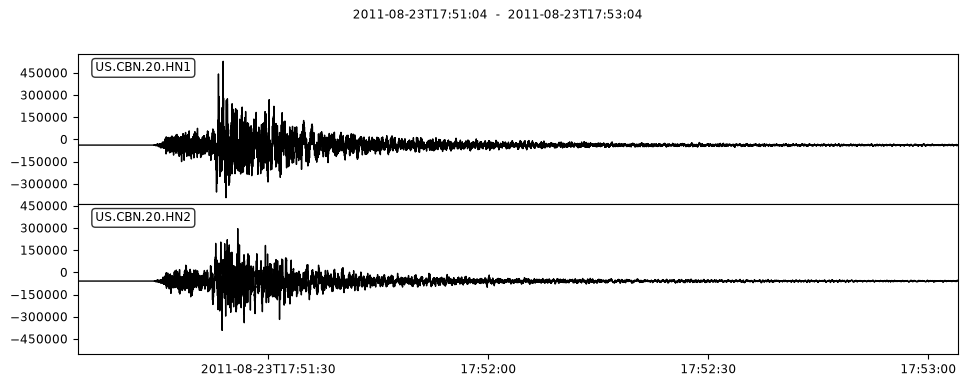

In [85]:
starttime = eventtime 
endtime = starttime + 2*60

sta_CBN_rawdata = client.get_waveforms(network = "US",
                                    station = "CBN",
                                    location = "*",
                                    channel = "HN1,HN2",
                                    starttime = starttime,
                                    endtime = endtime)
print(sta_CBN_rawdata)
sta_CBN_rawdata.plot(size=(1000,400));

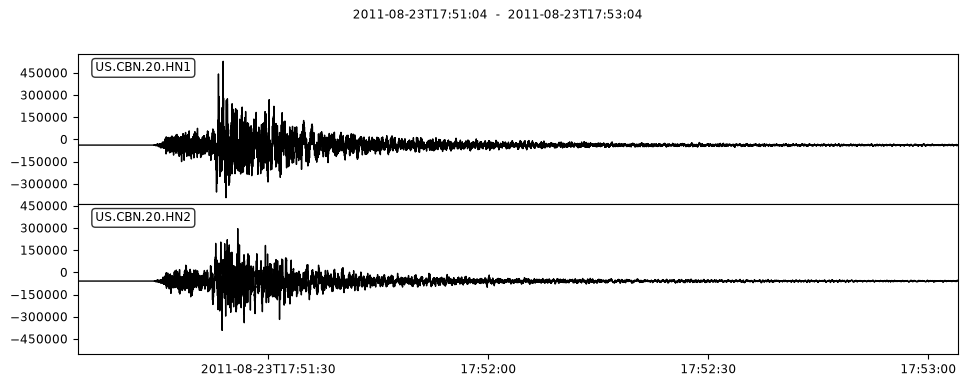

In [ ]:
baz_CBN = df_stations[df_stations['station'] == 'CBN'].back_azimuth
sta_CBN_rawdata.rotate(method="NE->RT", back_azimuth=baz_CBN.values[0])
sta_CBN_rawdata.plot(size=(1000,400));